# Importing Libraries

In [1]:
import math
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Load CSV

In [2]:
PROJECT_DIR = Path(os.environ.get("PROJECT_DIR", "/rs1/researchers/a/amallav")).resolve()
OUTPUTS_DIR=Path(os.environ.get("OUTPUTS_DIR", "/rs1/researchers/a/amallav/results")).resolve()
# OUTPUTS_BCCP_DIR = Path(os.environ.get("OUTPUTS_BCCP_DIR", OUTPUTS_DIR / "outputs_bioclip_crop")).resolve()
results_crop = OUTPUTS_DIR / "re.csv"
print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR, "| exists:", OUTPUTS_DIR.exists())
# print("OUTPUTS_BCCP_DIR:", OUTPUTS_BCCP_DIR, "| exists:", OUTPUTS_BCCP_DIR.exists())
print("results_crop:",results_crop, "| exists:", results_crop.exists())

PROJECT_DIR: /rs1/researchers/a/amallav
OUTPUTS_DIR: /rs1/researchers/a/amallav/results | exists: True
results_crop: /rs1/researchers/a/amallav/results/re.csv | exists: True


In [3]:
results_df = pd.read_csv(results_crop)
results_df

,Image_id,bounding_id,image_path,crop_file_path,x1,y1,x2,y2,species,score,box_num,user
0,obs_102691691_photo_171703626,obs_102691691_photo_171703626_1,/share/ftrscape/image_dataset/obs_102691691_ph...,/rs1/researchers/a/amallav/results/outputs_cro...,7.226631,17.393311,1356.330933,2030.399170,Egregia menziesii,0.625257,1,Egregia menziesii
1,obs_102691691_photo_171703626,obs_102691691_photo_171703626_1,/share/ftrscape/image_dataset/obs_102691691_ph...,/rs1/researchers/a/amallav/results/outputs_cro...,7.226631,17.393311,1356.330933,2030.399170,Alaria marginata,0.106859,1,Egregia menziesii
2,obs_102691691_photo_171703626,obs_102691691_photo_171703626_1,/share/ftrscape/image_dataset/obs_102691691_ph...,/rs1/researchers/a/amallav/results/outputs_cro...,7.226631,17.393311,1356.330933,2030.399170,Alaria crispa,0.030740,1,Egregia menziesii
3,obs_102691691_photo_171703626,obs_102691691_photo_171703626_1,/share/ftrscape/image_dataset/obs_102691691_ph...,/rs1/researchers/a/amallav/results/outputs_cro...,7.226631,17.393311,1356.330933,2030.399170,Alaria praelonga,0.029077,1,Egregia menziesii
4,obs_102691691_photo_171703626,obs_102691691_photo_171703626_1,/share/ftrscape/image_dataset/obs_102691691_ph...,/rs1/researchers/a/amallav/results/outputs_cro...,7.226631,17.393311,1356.330933,2030.399170,Alaria nana,0.028763,1,Egregia menziesii
...,...,...,...,...,...,...,...,...,...,...,...,...
1070,obs_64497720_photo_103704678,obs_64497720_photo_103704678_2,/share/ftrscape/image_dataset/obs_64497720_pho...,/rs1/researchers/a/amallav/results/outputs_cro...,664.636475,343.023560,1425.333740,758.643677,Bucephala albeola,0.398027,2,Alitta williami
1071,obs_64497720_photo_103704678,obs_64497720_photo_103704678_2,/share/ftrscape/image_dataset/obs_64497720_pho...,/rs1/researchers/a/amallav/results/outputs_cro...,664.636475,343.023560,1425.333740,758.643677,Platichthys stellatus,0.028262,2,Alitta williami
1072,obs_64497720_photo_103704678,obs_64497720_photo_103704678_2,/share/ftrscape/image_dataset/obs_64497720_pho...,/rs1/researchers/a/amallav/results/outputs_cro...,664.636475,343.023560,1425.333740,758.643677,Dorosoma cepedianum,0.026565,2,Alitta williami
1073,obs_64497720_photo_103704678,obs_64497720_photo_103704678_2,/share/ftrscape/image_dataset/obs_64497720_pho...,/rs1/researchers/a/amallav/results/outputs_cro...,664.636475,343.023560,1425.333740,758.643677,Lepomis cyanellus,0.022815,2,Alitta williami


In [4]:
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1075 entries, 0 to 1074
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Image_id        1075 non-null   str    
 1   bounding_id     1075 non-null   str    
 2   image_path      1075 non-null   str    
 3   crop_file_path  1075 non-null   str    
 4   x1              1075 non-null   float64
 5   y1              1075 non-null   float64
 6   x2              1075 non-null   float64
 7   y2              1075 non-null   float64
 8   species         1075 non-null   str    
 9   score           1075 non-null   float64
 10  box_num         1075 non-null   int64  
 11  user            1075 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 100.9 KB


# Make image grid
    

In [5]:
def get_rows_for_image(df, image_id, box_num_col="box_num"):
    rows = df[df["Image_id"] == image_id].copy()
    if rows.empty:
        return rows

    if box_num_col in rows.columns:
        rows = rows.sort_values(by=box_num_col)

    return rows

In [6]:
def load_original_image(rows, image_col="image_path"):
    original_path = rows.iloc[0][image_col]

    if pd.isna(original_path) or not os.path.exists(original_path):
        raise FileNotFoundError(f"Original image not found: {original_path}")

    return Image.open(original_path).convert("RGB"), original_path

In [7]:
def draw_bounding_boxes(
    original_img,
    rows,
    box_cols=("x1", "y1", "x2", "y2"),
    box_num_col="box_num"
):
    boxed_img = original_img.copy()
    draw = ImageDraw.Draw(boxed_img)

    if not all(col in rows.columns for col in box_cols):
        print(f"Missing bbox columns. Expected: {box_cols}")
        # print("Available columns:", list(rows.columns))
        return boxed_img

    x1_col, y1_col, x2_col, y2_col = box_cols

    # print(f"Trying to draw {len(rows)} boxes")

    for idx, r in rows.iterrows():
        try:
            x1 = float(r[x1_col])
            y1 = float(r[y1_col])
            x2 = float(r[x2_col])
            y2 = float(r[y2_col])

            # print(f"Row {idx}: ({x1}, {y1}, {x2}, {y2})")

            draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

            if box_num_col in rows.columns:
                draw.text((x1 + 5, y1 + 5), f"Box {r[box_num_col]}", fill="red")

        except Exception as e:
            print(f"Skipping row {idx} because of error: {e}")

    return boxed_img

In [8]:
def build_crop_title(
    row,
    box_num_col="box_num",
    label_col="species",
    user_col="user",
    score_col="score"
):
    parts = []

    if box_num_col in row.index and pd.notna(row[box_num_col]):
        parts.append(f"Box {row[box_num_col]}")

    if label_col in row.index and pd.notna(row[label_col]):
        val = "Model:" + str(row[label_col])
        parts.append(val)
        
    if user_col in row.index and pd.notna(row[user_col]):
        val = "User:" + str(row[user_col])
        parts.append(val)

    if score_col in row.index and pd.notna(row[score_col]):
        try:
            parts.append(f"{float(row[score_col]):.2f}")
        except Exception:
            parts.append(str(row[score_col]))

    return "\n".join(parts) if parts else "Crop"

In [9]:
def load_crop_images(
    rows,
    crop_col="crop_file_path",
    box_num_col="box_num",
    label_col="species",
    user_col="user",
    score_col="score"
):
    crop_images = []
    crop_titles = []

    for _, r in rows.iterrows():
        crop_path = r.get(crop_col, None)

        if pd.isna(crop_path) or not os.path.exists(crop_path):
            continue

        try:
            crop_img = Image.open(crop_path).convert("RGB")
            crop_images.append(crop_img)

            title = build_crop_title(
                r,
                box_num_col=box_num_col,
                label_col=label_col,
                user_col=user_col,
                score_col=score_col
            )
            crop_titles.append(title)

        except Exception as e:
            print(f"Could not load crop: {crop_path} | {e}")

    return crop_images, crop_titles

In [10]:
def build_panels_and_titles(original_img, boxed_img, crop_images, crop_titles):
    panels = [original_img, boxed_img] + crop_images
    titles = ["Original", "Bounding_boxes"]+ crop_titles
    return panels, titles

In [11]:
def create_figure_layout(n_panels, dpi=150):
    ncols = min(4, n_panels)
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 5 * nrows),
        dpi=dpi
    )

    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    return fig, axes

In [12]:
def plot_panels(fig, axes, panels, titles, image_id):
    for ax, img, title in zip(axes, panels, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis("off")

    for ax in axes[len(panels):]:
        ax.axis("off")

    fig.suptitle(f"Image ID: {image_id}", fontsize=16)
    plt.tight_layout()


In [13]:
def save_figure(fig, image_id, save_dir):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    out_path = save_dir / f"grid_{image_id}.png"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Saved: {out_path}")

    return out_path

In [13]:
def make_image_crop_grid(
    df,
    image_id,
    image_col="image_path",
    crop_col="crop_file_path",
    box_cols=("x1", "y1", "x2", "y2"),
    label_col="species",
    user_col="user",
    score_col="score",
    box_num_col="box_num",
    save_dir=None,
    show=True,
    dpi=150
):
    rows = get_rows_for_image(df, image_id, box_num_col=box_num_col)

    if rows.empty:
        print(f"No rows found for image_id={image_id}")
        return None

    try:
        original_img, _ = load_original_image(rows, image_col=image_col)
    except FileNotFoundError as e:
        print(e)
        return None

    boxed_img = draw_bounding_boxes(
        original_img,
        rows,
        box_cols=box_cols,
        box_num_col=box_num_col
    )

    crop_images, crop_titles = load_crop_images(
        rows,
        crop_col=crop_col,
        box_num_col=box_num_col,
        user_col=user_col,
        label_col=label_col,
        score_col=score_col
    )

    panels, titles = build_panels_and_titles(
        original_img,
        boxed_img,
        crop_images,
        crop_titles
    )

    fig, axes = create_figure_layout(len(panels), dpi=dpi)
    plot_panels(fig, axes, panels, titles, image_id)

    # out_path = None
    # if save_dir is not None:
    #     out_path = save_figure(fig, image_id, save_dir)

        # if show:
        #     plt.show()
        # else:
        #     plt.close(fig)

    # return fig, out_path

# Execution


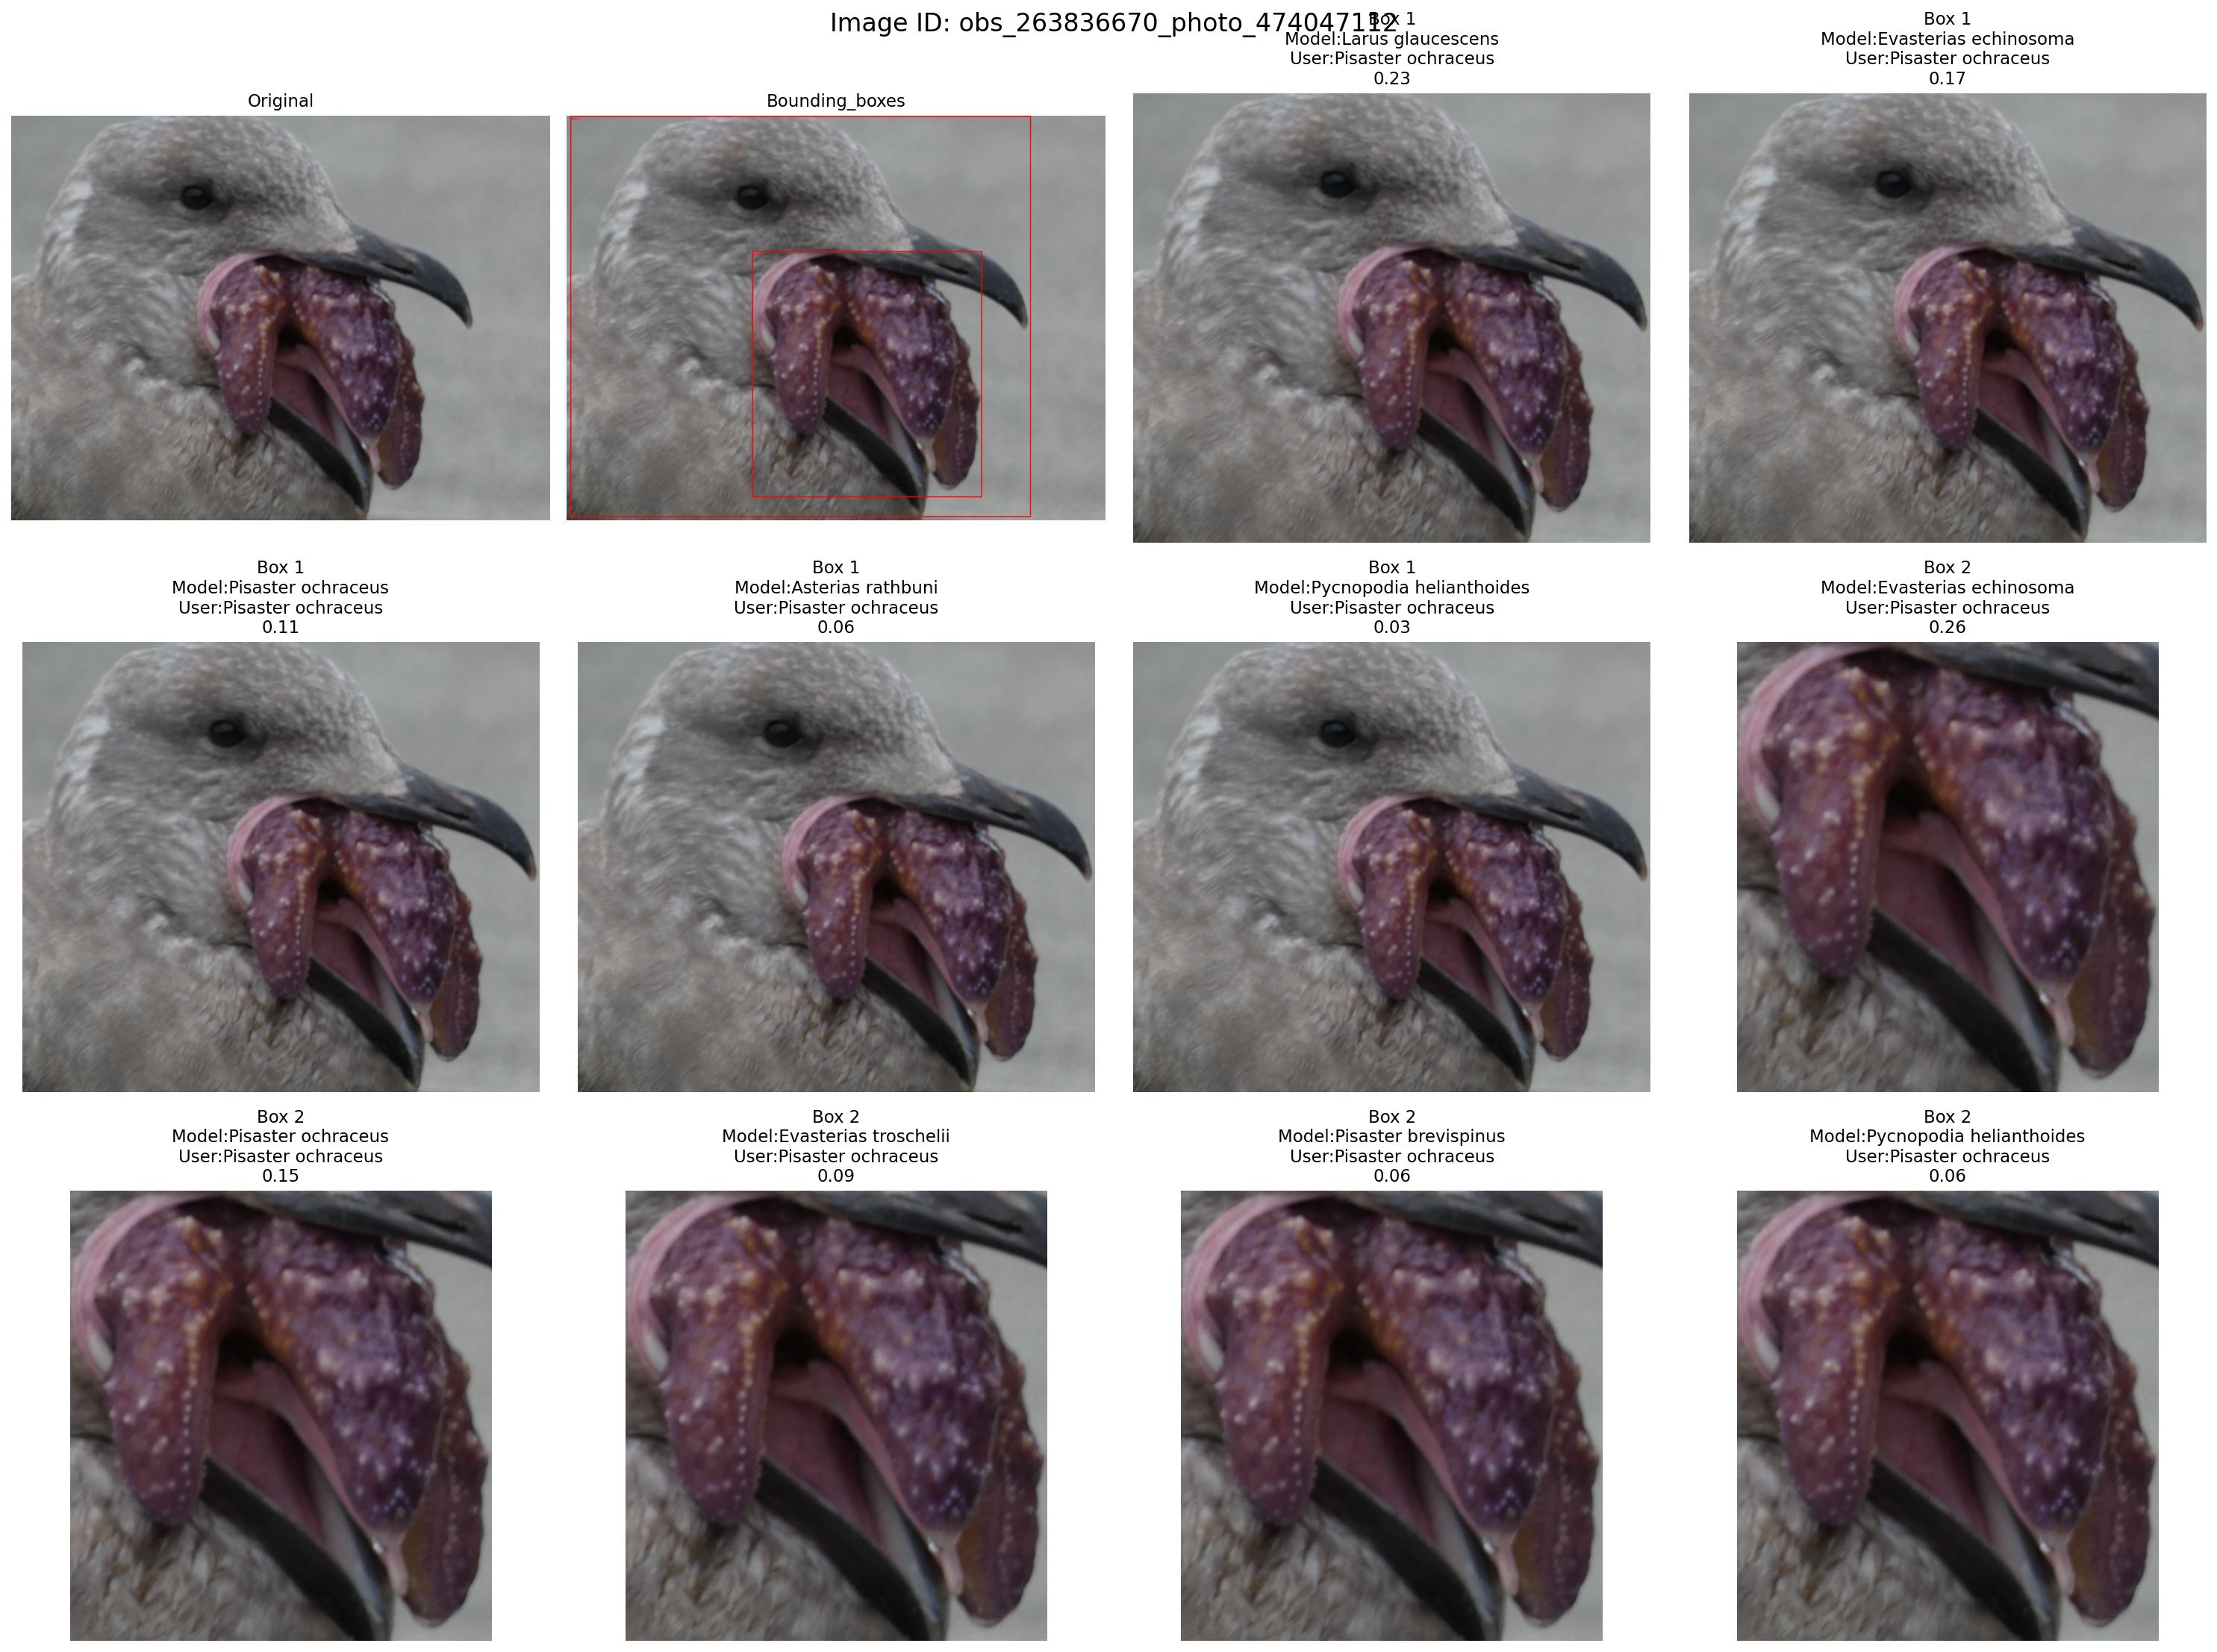

In [23]:

make_image_crop_grid(
    df=results_df,
    image_id="obs_263836670_photo_474047112",
    image_col="image_path",         
    crop_col="crop_file_path",
    box_cols=("x1", "y1", "x2", "y2"),  
    label_col="species",
    score_col="score",
    box_num_col="box_num",
    save_dir="grid_outputs"
)